# Portfolio Optimization via James-Stein Eigenvector Regularization
**Author:** Jonathan Cushman  
**Date:** April 2026  
**Abstract:** This project addresses the challenge of portfolio optimization in a High-Dimension, Low-Sample Size regime. To resolve the singularity of the sample covariance matrix, we implement a Single-Factor Market Model regularized by applying the James-Stein Estimator (JSE) to the leading eigenvector. Results demonstrate that JSE shrinkage effectively filters sampling noise, producing a more stable weight distribution and a robust Global Minimum Variance (GMV) portfolio that significantly outperforms the S&P 500 benchmark in risk reduction.

## Project Description 
This project focusees on the construction and evaluation of a Global Minimum Variance (GMV) Portfolio using a universe of the top 400 stocks from the S&P 500 over a 26-week time period. Because the number of assets $(p=400)$ greatly exceeds the number of obeservation $(n=26)$, the sample covariance matrix is singular and cannot be inverted for traditional Markowitz optimization 

The resolve this issue, we implement a Single-Factor Market Model and apply the James-Stein Estimator (JSE) to the leading eigenvector as suggested by Goldbergh and Kercheval (2022). This eigenvector shrinkage corrects for the bias and excess dispersion found in high-dimensional datasets. We compare the JSE-regularized portfolio against the traditional PCA-based Factor Model and the S&P 500 benchmark (SPY) across metrics such as annualized variance $\sigma^2$, expected excess returns $f$, and the Sharpe Ratio $SR$ to determine the effects. 

## Importing Necessary Libraries

In [1]:
import numpy as np # Linear Algebra
import requests, pandas as pd # Data Manipulation
import yfinance as yf # Stock Data
from io import StringIO # Web Scraping
import matplotlib.pyplot as plt # Plotting
from matplotlib.ticker import PercentFormatter # Plotting Add-On 

## Web Scrape for Stock Tickers
To define the universe of our investments, we utilized the Wikipedia API to retrieve the current members and associated tickers of the S&P 500. Using Python's requests library, we are able to fetch the content as a JSON object and extracts the table via the pandas and StringIO libraries. The tickers are then extracted from the table and stored as list. 

Attachehed here is a reference link to the video for the code - https://www.youtube.com/watch?v=9gsn_9lh6uk

In [2]:
# Define wikipedia API endpoint 
API = 'https://en.wikipedia.org/w/api.php'

# Parameters to request the 'List of S&P 500 companies' page parsed as JSON
params = {
    'action': 'parse',
    'page': 'List_of_S&P_500_companies', 
    'prop': 'text', 
    'format': 'json'
}

# Identity header to prevent the API from blocking the request
headers = {'User-Agent': 'sp500-ticker-tutorial/1.0'}
r = requests.get(API, params = params, headers = headers)
html = r.json()['parse']['text']['*']

# Read the HTML table into a DataFrame and extract the symbol column as a list
df = pd.read_html(StringIO(html))[0]
tickers = df['Symbol'].astype(str).tolist()

## Data Importation and Organization
To ensure compatibility with the yfinance API, S&P 500 tickers were standardized by replacing internal periods with hyphens ("BRK.B" to "BRK-B"). We then defined a 26-week observation window to download weekly closing prices. To isolate the most significant assets, we filtered the universe to the top 400 stocks by market capitalization.
$$\text{Market Cap.} = \text{Closing Price} \times \text{Shares Outstanding} $$ 

Market capitalization was estimated by multiplying the most recent closing price in our dataset by the current number of outstanding shares retrieved via stock.info. While this assumes share counts remained relatively stable over the 26-week period, it provides a consistent metric for ranking. After sorting the assets, a final data-integrity check was performed to ensure there are no missing values before proceeding to the covariance estimation.

In [3]:
# Remove unusable tickers for yfinance api 
for bad in ["BRK.B", "BF.B"]:
    if bad in tickers:
        tickers.remove(bad)

# add usable tickers
tickers = tickers + ["BRK-B","BF-B"]

# Define Date Range
start_date = "2025-05-26"
end_date = "2025-11-28"

# Download raw data for all tickers 
data = yf.download(tickers, start=start_date, end=end_date, interval="1wk")
closing_prices = data['Close']

# Download raw data for S&P500 benchmark 
spy_data = yf.download("SPY", start=start_date, end=end_date, interval="1wk")
spy_prices = spy_data['Close']

# initialize storage for dictionary
results = [] 

# loop through each ticker 
for ticker in tickers:
    try:
        # grab the most recent price and the number of outstanding shares
        last_price = closing_prices[ticker].dropna().iloc[-1] 
        stock = yf.Ticker(ticker)
        shares = stock.info.get('sharesOutstanding')

        if shares != None:
            # Compute market cap for individual tickers
            m_cap = last_price * shares
            # append ticker and associated market cap data to dictionary
            results.append({'Ticker': ticker, 'MarketCap': m_cap})
            
    except Exception: 
        continue 

# convert to dataframe for easier use
dataframe = pd.DataFrame(results)
# sort from largest to smallest and grab top 400 elements
top_400 = dataframe.sort_values(by='MarketCap', ascending=False).head(400)

# store top 400 tickers in list
top_400_tickers = top_400["Ticker"].tolist() 
# Download data again but this time for top 400 tickers
top_400_data = yf.download(top_400_tickers, start= start_date, end = end_date, interval = "1wk")
top_400_close = top_400_data["Close"]

# Check for missing values in data 
missing_counts = top_400_close.isna().sum().sum()
if missing_counts == 0:
    print("The Data contains no missing values")
else: 
    print(f"The Data contains {missing_counts} missing values")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  503 of 503 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  400 of 400 completed


The Data contains no missing values


## Constructing the Sample Covariance Matrix
Using the now clean data we can create the returns matrix $R$ by taking the weekly percent changes for our dataset.
$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}} $$
Taking the transpose $R^T$ we are now able to create the proper dimensions (400 x 26) for computation. We then subtract the weekly risk fre rate $r_{week} = 0.0375/52$ obtained from a 6-month treasury bond to yield the excess returns matrix $E$. 
$$ E = R^T - r_{week} $$

Next we compute the average excess weekly return for each stock $\mu$, and subtract the mean from each observation to create the de-meaned excess returns matrix $Y$ for use in computing the sample covariance matrix
$$ Y = E - \mu \rightarrow S = YY^T/n$$ 

In [4]:
# Create the returns matrix and take the transpose for required shape
returns = top_400_close.pct_change().dropna() 
returns_matrix = returns.T.to_numpy()

# create return vector for benchmark 
spy_returns = spy_prices.pct_change().dropna()

# 6-month treasury yield rates
risk_free_rate = 0.0375 
weekly_RFR = risk_free_rate/52 

# Excess Returns Formula
excess_returns_matrix = returns_matrix - weekly_RFR 
spy_excess_returns = spy_returns - weekly_RFR

# axis=1 takes mean of each row and creates a column vector of each stocks mean 
excess_returns_mean_vector = excess_returns_matrix.mean(axis=1, keepdims= True)

# Creating the p x n de-meaned excess returns matrix Y
Y = excess_returns_matrix - excess_returns_mean_vector

# calculate sample covariance matrix S
S = (Y @ Y.T) / 26 

## Compute JSE-Estimator for Leading Eigenvector
As we identified last time, this sample covariance matrix is not invertible in this scenario as it has a maximal rank of 26, meaning we are unable to take the inverse of this matrix for use in our calculations for the GMV portfolio. 

To combat this we used a single-factor market model to estimate the covariance matrix S via the form: 
$$\Sigma = (\lambda^2- \ell^2)hh^T + (n/p)\ell^2 I$$ 

where $n$ is the number of observations, $p$ is the number of assets. $\lambda^2$ is the leading eiganvalue of $S$ and $h$ is its corresponding unit eigenvector. $I$ is the identity matrix and $\ell^2 $ is the average of the non-zero eigenvalues that are less than $\lambda^2$ such that: 
$$\ell^2 = \frac{tr(S)-\lambda^2}{n-1}$$
    
We now want to further improve upon this estimate by substituting $h^{JSE}$ for $h$. In doing this we now have the equation: 
$$\Sigma_{JSE} = (\lambda^2- \ell^2)\frac{h^{JSE}(h^{JSE})^T}{|h^{JSE}|^2} + (n/p)\ell^2 I$$ 

where the JSE estimator $h^{JSE}$ is defined by the shrinking the entries of $h$ towards their average $m(h)$ via the formula: 
$$h^{JSE} = m(h)e + c^{JSE}(h-m(h)e)$$ 

where $e$ is the p-dimensional vector of ones and $c^{JSE}$ is the shrinage constant given by: 
$$c^{JSE} = 1 - \frac{\nu^2}{s^2(h)}$$

$s^2(h)$ is the measure of the variation of the entries $\lambda h$ around their average $\lambda m(h)$:
$$s^2(h) = \frac{1}{p} \sum_{i=1}^p (\lambda h_i - \lambda m(h))^2$$ 

And $\nu^2$ is equal to the average of the nonzero smaller eigenvalues of $S$ scaled by $(1/p)$:
$$\nu^2 = \frac{tr(S) - \lambda^2}{p(n-1)}$$

$\Sigma_{JSE}$ acts as a regularization technique by preforming a spectral shift, which in turn lifts the zero eigenvalues by shifting them upwards by at least $\frac{\ell^2 n}{p}$. This in turn ensures that the determinant is strictly positive and therefore invertible. 

This shrinkage filters out the sampling noise that would otherwise lead to extreme and incorrect portfolio weights. By shrinking the eigenvevtor, the JSE produces a covariance matrix that is more stable. While it might have a slightly higher variance on the current data (in-sample), it is much more likely to maintain a low variance on future data (out-of-sample). The JSE is designed specifically to be a consistent estimator in the asymptotic HL regime by pulling the estimate closer to the true population eigenvector

In [8]:
p = 400  # number of assets
n = 26 # number of samples/weeks

# Compute eigen-pairs for S 
eigenvalues_S, eigenvectors_S = np.linalg.eigh(S)

# Compute leading eiganval and corresponding unit vector
lambda_sq = eigenvalues_S[-1]
h = eigenvectors_S[:,-1].reshape(-1,1)

# Compute ell_sq
trace_S = np.trace(S)
ell_sq = (trace_S - lambda_sq) / (n - 1)

# compute m(h)
m_h = h.mean()
ones = np.ones((p,1))

# Compute nu_sq
nu_sq = (trace_S - lambda_sq) / (p * (n-1)) 

#compute s_sq(h)
s_sq = (lambda_sq / p) * np.sum((h - m_h)**2) 

#compute c_jse - ensure does not go negative
c_jse = max(0, 1 - (nu_sq / s_sq)) 

#Compute h_jse = term1 + term2 
h_jse_term_1 = m_h * ones
h_jse_term_2 = c_jse * (h - (m_h * ones))
h_jse = h_jse_term_1 + h_jse_term_2

# compute normalization constant
h_jse_norm_sq = np.linalg.norm(h_jse)**2

# Compute JSE Cov. Matrix 
Sigma_jse_term1 = (lambda_sq - ell_sq) * (h_jse @ h_jse.T) / h_jse_norm_sq
Sigma_jse_term2 = (n / p) * ell_sq * np.eye(p)
Sigma_jse = Sigma_jse_term1 + Sigma_jse_term2

# Assemble Single-Factor Model Covariance Matrix
Sigma_pca_term1 = (lambda_sq - ell_sq) * (h @ h.T)
Sigma_pca_term2 = (26/400) * ell_sq * np.eye(400)
Sigma_pca = Sigma_pca_term1 + Sigma_pca_term2

# grab eigenvalues and eiganvectors from both pca and jse 
eigenvalues_pca, eigenvectors_pca = np.linalg.eigh(Sigma_pca)
eigenvalues_jse, eigenvectors_jse = np.linalg.eigh(Sigma_jse)
h_pca = eigenvectors_pca[:, -1].reshape(-1, 1)
h_jse = eigenvectors_jse[:, -1].reshape(-1, 1)

# Check if they are pointing in opposite directions
if np.dot(h.T, h_pca) < 0:
    h_pca = -h_pca

if np.dot(h.T, h_jse) < 0:
    h_jse = -h_jse

#Compute MSE between eigenvectors 
mse_eiganvector_pca = np.mean((h - h_pca)**2)
mse_eiganvector_jse = np.mean((h - h_jse)**2)

## Compute GMV Portfolio 
Now that we have computed the JSE single factor market model for the covariance matrix $\Sigma_{JSE}$, can use it interchangeably with $\Sigma$ on our formulas from last time to compute the GMV portfolio holding vector $h_C$, variance $\sigma^2_C$, standard deviation $\sigma_C$, beta $\beta_C$, expected excess returns $f_C$, and Sharpe Ratio $SR_C$: 
$$
h_C = \frac {\Sigma^{-1}e}{e^T\Sigma e}, \quad \sigma^2_C = h^T_C \Sigma h_C, \quad \beta_C = \frac{\Sigma h_C}{ \sigma^2_C}, \quad f_C=h^T_C \mu, \quad SR_C = \frac{f_C}{\sigma_C} 
$$

In addition, we want to capture the individual stock variances stored on the diagonal of the covariance matrix via the identity 
$$Cov(Stock_i,Stock_j) = Cov(Stock_i,Stock_i) = Var(Stock_i) \quad \text{if} \ i = j $$

Among these individual variances we will capture the mean and minimum from the individual stock variances as a means for comparison against our constructed portfolios

In [11]:
# Compute Inverses 
Sigma_pca_inverse = np.linalg.inv(Sigma_pca)
Sigma_jse_inverse = np.linalg.inv(Sigma_jse)

# Compute Holdings Vectors
holding_C_pca = (Sigma_pca_inverse @ ones) / (ones.T @ Sigma_pca_inverse @ ones)
holding_C_jse = (Sigma_jse_inverse @ ones) / (ones.T @ Sigma_jse_inverse @ ones)

# Compute Variances
Variance_C_pca = (holding_C_pca.T @ Sigma_pca @ holding_C_pca)
Variance_C_jse = (holding_C_jse.T @ Sigma_jse @ holding_C_jse)
annual_variance_C_pca = Variance_C_pca * 52 
annual_variance_C_jse = Variance_C_jse * 52

# Compute std. deviations
std_dev_C_pca = np.sqrt(Variance_C_pca)
std_dev_C_jse = np.sqrt(Variance_C_jse)
annual_std_dev_C_pca = std_dev_C_pca * np.sqrt(52)
annual_std_dev_C_jse = std_dev_C_jse * np.sqrt(52)

# Compute expected excess returns 
expected_excess_returns_C_pca = holding_C_pca.T @ excess_returns_mean_vector
expected_excess_returns_C_jse = holding_C_jse.T @ excess_returns_mean_vector
annual_expected_excess_returns_C_pca = expected_excess_returns_C_pca * 52 
annual_expected_excess_returns_C_jse = expected_excess_returns_C_jse * 52 

# Compute Betas
Beta_C_pca = (Sigma_pca @ holding_C_pca) / Variance_C_pca
Beta_C_jse = (Sigma_jse @ holding_C_jse) / Variance_C_jse

# Compute Individual Stock Variances
individual_variance_pca = np.diag(Sigma_pca)
individual_variance_jse = np.diag(Sigma_jse)
annual_individual_variance_pca = individual_variance_pca * 52
annual_individual_variance_jse = individual_variance_jse * 52

# Compute Individual Stock Mean Variances
mean_variance_pca = annual_individual_variance_pca.mean()
mean_variance_jse = annual_individual_variance_jse.mean()

# Compute Minimum Individual Stock Variances
min_variance_pca = np.argmin(annual_individual_variance_pca)
min_variance_jse = np.argmin(annual_individual_variance_jse)
lowest_val_pca = annual_individual_variance_pca[min_variance_pca]
lowest_val_jse = annual_individual_variance_jse[min_variance_jse]

# Compute Benchmark Variance, standard deviation, and expected excess returns
spy_annual_variance = spy_excess_returns.var() * 52
spy_annual_std_dev = np.sqrt(spy_annual_variance)
spy_annual_expected_excess_returns = spy_excess_returns.mean() * 52

# Compute Sharpe Ratios 
SR_pca = annual_expected_excess_returns_C_pca.item() / annual_std_dev_C_pca
SR_jse = annual_expected_excess_returns_C_jse.item() / annual_std_dev_C_jse
SR_spy = spy_annual_expected_excess_returns.iloc[0] / spy_annual_std_dev.iloc[0]

## Factor Model Analysis and Distribution
Attached below is a visualization for the distribution of eiganvalues and portfolio weights.

The first plot illustrates the decay of eiganvalue magnitudes from the sample covariance matrix $S$. The leading eiganvalue $\lambda^2$, sometimes referred to as the leading principal component, represents the systematic risk shared by all $400$ stocks. The rapid decline from the first to second eiganvalue justifies the use of the Single Factor Model by isolating $\lambda^2$ and averaging the noise into term $\ell^2$.

The second plot compares the distribution of weights between the holding vectors $h_C$ for the PCA and JSE Single Factor Models. This displays how to capital is allocated across the top $400$ assets. We notice that most of the spread is near the center of the distribution for our PCA method, while the JSE method increased the spatial dispersion of the weights. High dispersion usually indicates that individual components of a dataset are behaving differently, which can mean more risk but also higher potential for finding outliers.

The lower dispersion of weights around the mean for the PCA based method is what allows the in-sample data to be optimized, while the JSE method optimizes the out-of-sample data by dragging the leading eigenvector towards the true mean, eliminating noise within the model. 

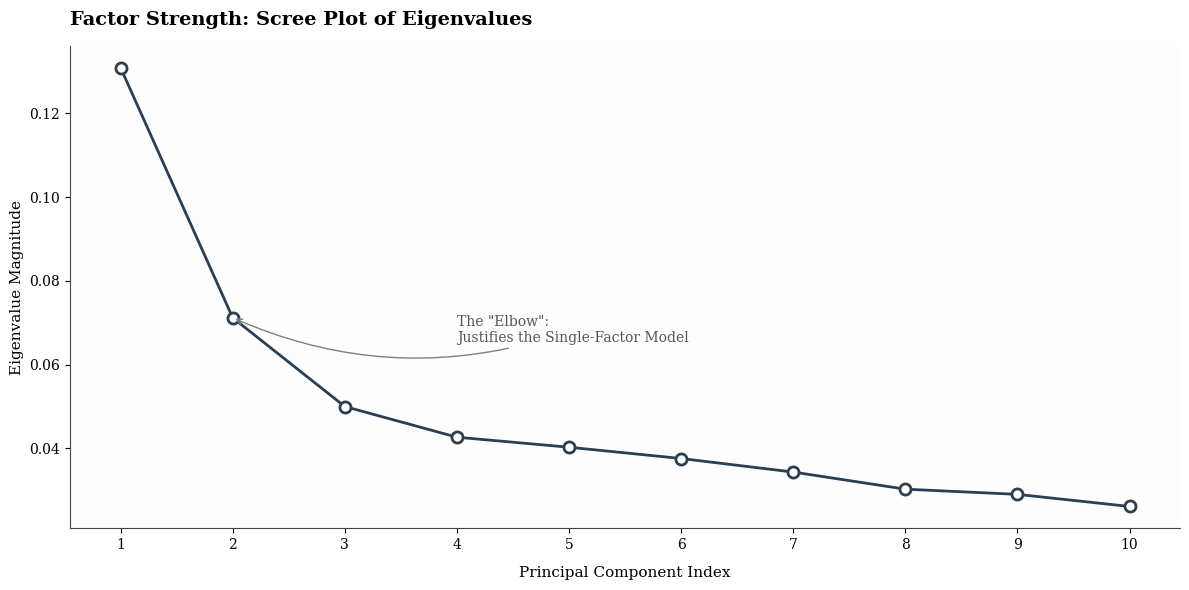

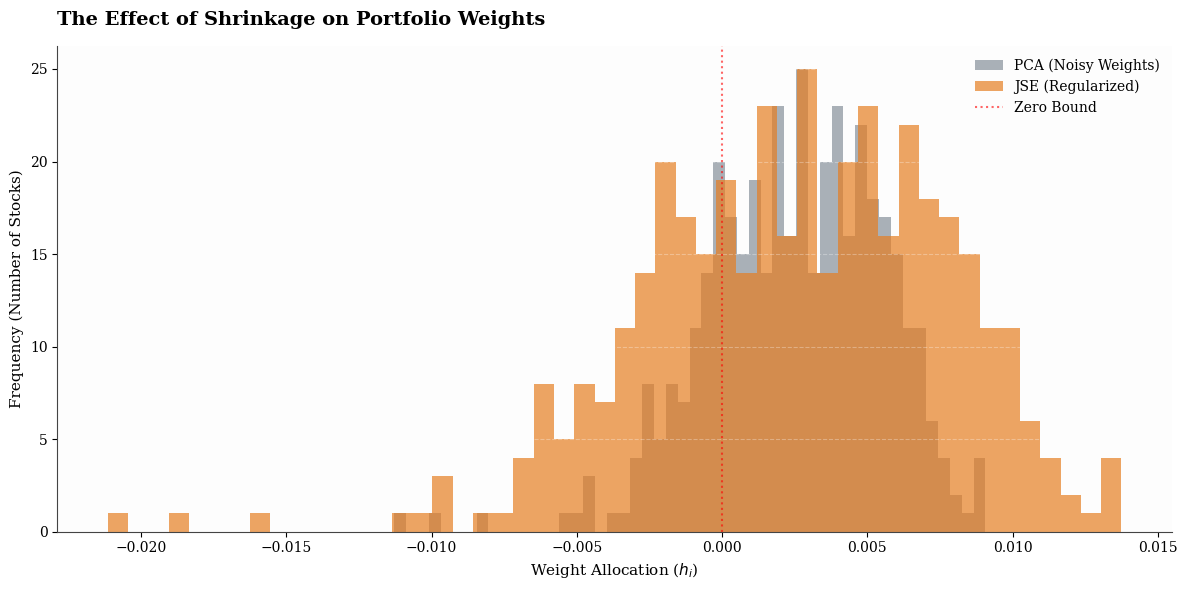

In [32]:
plt.figure(figsize=(12, 6))

# Ensure eigenvalues are computed
sorted_evals = np.sort(eigenvalues_S)[::-1]

plt.plot(range(1, 11), sorted_evals[:10], marker='o', color=colors['pca'], linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)

plt.title('Factor Strength: Scree Plot of Eigenvalues', loc='left', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Component Index', fontsize=11, labelpad=10)
plt.ylabel('Eigenvalue Magnitude', fontsize=11)
plt.xticks(range(1, 11))
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add elbow annotation
plt.annotate('The "Elbow":\nJustifies the Single-Factor Model', 
             xy=(2, sorted_evals[1]), xytext=(4, sorted_evals[0]*0.5),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-.2', color='grey'),
             fontsize=10, color='#555555')

# Remove top/right spines for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# --- 2. THE WEIGHT DISTRIBUTION (Full Width) ---
plt.figure(figsize=(12, 6))

plt.hist(holding_C_pca.flatten(), bins=50, color=colors['pca'], alpha=0.4, label='PCA (Noisy Weights)', edgecolor='none')
plt.hist(holding_C_jse.flatten(), bins=50, color=colors['jse'], alpha=0.7, label='JSE (Regularized)', edgecolor='none')

plt.title('The Effect of Shrinkage on Portfolio Weights', loc='left', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Weight Allocation ($h_i$)', fontsize=11)
plt.ylabel('Frequency (Number of Stocks)', fontsize=11)
plt.axvline(0, color='red', linestyle=':', alpha=0.6, label='Zero Bound')

plt.legend(frameon=False, loc='upper right')

# Remove top/right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Results and Conclusion
The final course of action is to now oberserve and compare the results from our model. As seen below, the constructed portfolios both resulted in a significant risk reduction compared to our bench mark portfolio (SPY). The PCA-GMV portfolio has an annualized variance of $\sigma^2_C = 0.000478$ which is a large reduction compared to the JSE-GMV Portfolio annualized variance at $\sigma^2_C = 0.001072$. Both GMV portfolios reported a significant decrease in variance compared to the benchmark along with the mean and minimum individual stock metrics. This significant drop empirically provides evidence that the optimization process is working as theoretically intended to reduce risk.

While it may be counterintuitive, the PCA model looks better due to the lower variance but this is due to the in-sample overfitting. The PCA model is finding the absolute lowest variance possible using its past data. On the other hand, JSE model is designed to intentionally be more stable on future data (out-of-sample). 

Looking at the shrinkage constant $c^{JSE} = 0.5588$ the model interprested that over $44%$ of the signal within the sample eigenvector $h$ was noise within the market data, effective pulling toward an equal weighted distribution. This can also be analyzed through the lens of the mean squared error between the eigenvectors $h^{PCA}$ and $h^{JSE}$ and the sample eigenvector $h$. The results show that the PCA model replicates the sample eigenvector while the JSE model is varying the direction of the sample eigenvector pulling it away from the market noise. 

Analyzing the Sharpe Ratio next, we observe that the JSE model performed substantially worse than our benchmark and PCA model. While this may be worrisome to most, this is actually a good indicator that our portfolio is working as intended. Recalling that we are computing the GMV portfolio, returns are not taken into account when identifying the weight distributions. Even though the return is negative, the PCA model portfolio still greatly reduced the variance compared to our benchmark.  

Through the evidence gathered in this project I would not recommend this portfolio to someone. As evidenced, the JSE model is our best estimate for High-dimensional data sets with low sample sizes. This portfolio does a great job of minimizing risk but at the cost of having a negative sharpe ratio. We can conclude by stating that the JSE estimator acts as insurnace where if we pay a small price in the performance today we can avoid a total collapse when the market regime changes tomorrow. 

In [20]:
print("\n------ JSE REGULARIZATION STATS ------")
print(f"Shrinkage Constant (c_jse): {c_jse:.4f}") 
print(f"MSE (Sample h vs JSE h):    {mse_eiganvector_jse:.8f}")
print(f"MSE (Sample h vs PCA h):    {mse_eiganvector_pca:.8f}")

print("\n------ GMV PORTFOLIO PERFORMANCE COMPARISON ------")
print(f"{'Metric':<25} | {'PCA Model':<12} | {'JSE Model':<12} | {'SPY (Bench)'}")
print("----------------------------------------------------")

# Annualized Variance
v_pca = annual_variance_C_pca.item()
v_jse = annual_variance_C_jse.item()
v_spy = spy_annual_variance.iloc[0]
print(f"{'Annualized Variance':<25} | {v_pca:.6f}     | {v_jse:.6f}     | {v_spy:.6f}")

# Annualized Standard Deviation
print(f"{'Annualized Std Dev':<25} | {annual_std_dev_C_pca.item():.6f}     | {annual_std_dev_C_jse.item():.6f}     | {spy_annual_std_dev.iloc[0]:.6f}")

# Expected Excess Return
r_pca = annual_expected_excess_returns_C_pca.item()
r_jse = annual_expected_excess_returns_C_jse.item()
r_spy = spy_annual_expected_excess_returns.iloc[0]
print(f"{'Expected Excess Return':<25} | {r_pca:.6f}     | {r_jse:.6f}    | {r_spy:.6f}")

# Sharpe Ratio (Efficiency)
print(f"{'Sharpe Ratio':<25} | {np.array(SR_pca).item():.4f}       | {np.array(SR_jse).item():.4f}      | {np.array(SR_spy).item():.4f}")
print(f"{'Average Portfolio Beta':<25} | {Beta_C_pca.mean():.4f}       | {Beta_C_jse.mean():.4f}")

print("\n------ INDIVIDUAL ASSET BENCHMARK ------")
print(f"{'Mean Stock Variance':<25} | {mean_variance_pca:.6f}     | {mean_variance_jse:.6f}")
print(f"{'Min. Stock Variance':<25} | {lowest_val_pca:.6f}     | {lowest_val_jse:.6f}")


------ JSE REGULARIZATION STATS ------
Shrinkage Constant (c_jse): 0.5588
MSE (Sample h vs JSE h):    0.00016069
MSE (Sample h vs PCA h):    0.00000000

------ GMV PORTFOLIO PERFORMANCE COMPARISON ------
Metric                    | PCA Model    | JSE Model    | SPY (Bench)
----------------------------------------------------
Annualized Variance       | 0.000478     | 0.001072     | 0.013402
Annualized Std Dev        | 0.021860     | 0.032743     | 0.115765
Expected Excess Return    | 0.030964     | -0.106052    | 0.277219
Sharpe Ratio              | 1.4165       | -3.2389      | 2.3947
Average Portfolio Beta    | 1.0000       | 1.0000

------ INDIVIDUAL ASSET BENCHMARK ------
Mean Stock Variance       | 0.090108     | 0.090108
Min. Stock Variance       | 0.076022     | 0.076033
